In [27]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
import os
import pandas as pd
from PIL import Image
import torch
import math
import matplotlib.colors as colors
import matplotlib.patches as patches

### Draw one VAE reconstruction with ground truth

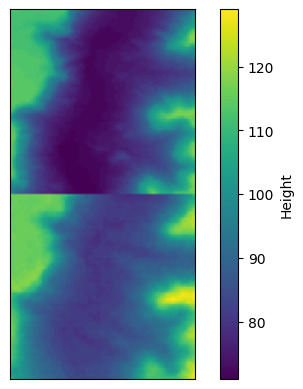

In [ ]:
data_dir = '../results/usgs_d_power_best_98/output.png'
img_num = 2

offset = img_num * 64
img = Image.open(data_dir)
arr = np.array(img)[:, offset:offset+64, 0]
fig, ax = plt.subplots()
im = ax.imshow(arr, cmap = 'viridis')
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(im, ax = ax, label = "Height")

### Show difference between reconstruction and input

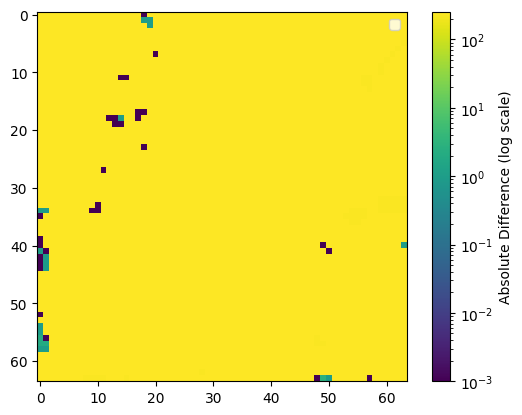

In [15]:
img_num = 2

offset = img_num * 64
diff_array = np.abs(np.array(img)[:64, offset:offset+64, 0] - np.array(img)[64:, offset:offset+64, 0])
# Add a small constant to avoid log(0)
im = plt.imshow(diff_array + 1e-3, cmap='viridis', norm=colors.LogNorm())
plt.colorbar(im, label='Absolute Difference (log scale)')
plt.legend(['Patch difference'])

### 1 step outpainting and reconstruction side by side

/tmp/ipykernel_57654/2362007604.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


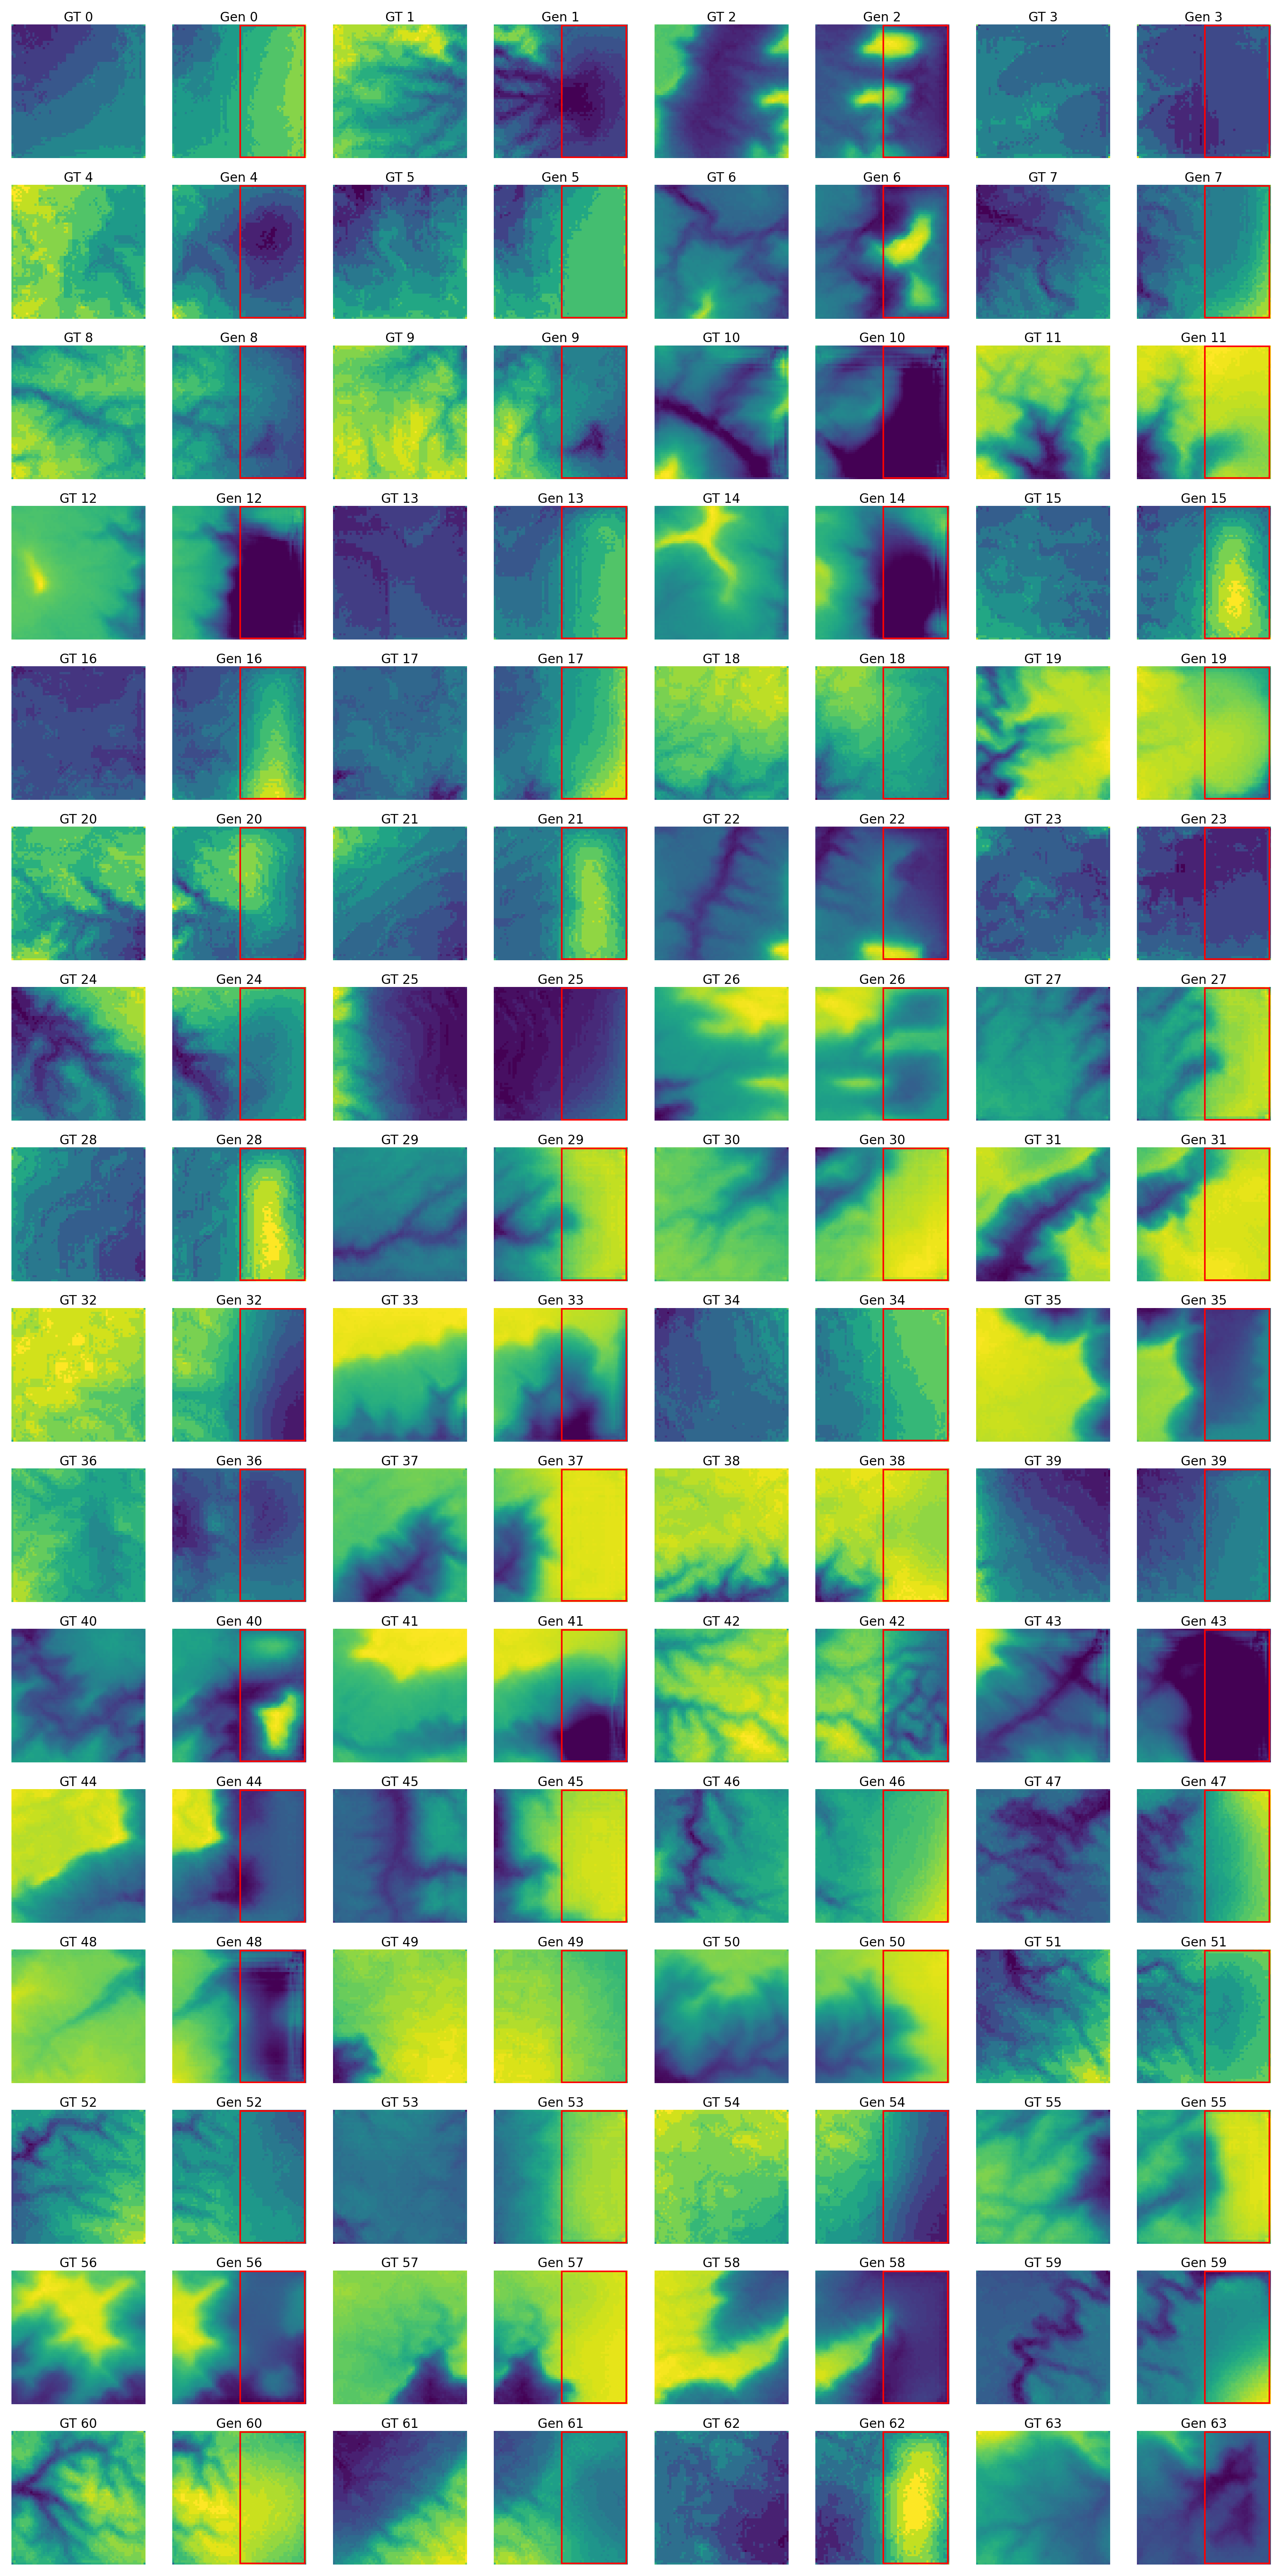

In [31]:
data_dir = "../results/transformer_best_99_testtesttest/output.png"

# Load image and select first channel
img = Image.open(data_dir)
arr = np.array(img)[:, :, 0]

img_size = 64
num_images = arr.shape[1] // img_size  # Total image pairs

# Top row = Generated, Bottom row = Ground Truth
gen_row = arr[:img_size, :]
gt_row = arr[img_size : img_size * 2, :]

# Grid configuration: Each pair takes 2 adjacent columns
cols_pairs = 4  # 4 pairs = 8 total columns wide
rows = int(np.ceil(num_images / cols_pairs))
cols = cols_pairs * 2

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * 1.8, rows * 1.8),
    dpi=300,  # High resolution for zooming
    gridspec_kw={
        "wspace": 0.05,
        "hspace": 0.2,
    },
)

axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i in range(num_images):
    # Slice individual 64x64 tiles
    gen_tile = gen_row[:, i * img_size : (i + 1) * img_size]
    gt_tile = gt_row[:, i * img_size : (i + 1) * img_size]

    # Compute shared intensity bounds across the pair
    pair_min = min(gen_tile.min(), gt_tile.min())
    pair_max = max(gen_tile.max(), gt_tile.max())

    # Map placement (GT on left, Gen on right)
    idx_gt = i * 2
    idx_gen = i * 2 + 1

    # Plot Ground Truth (no bounding box)
    axes_flat[idx_gt].imshow(
        gt_tile, cmap="viridis", vmin=pair_min, vmax=pair_max
    )
    axes_flat[idx_gt].set_title(f"GT {i}", fontsize=8, pad=2)
    axes_flat[idx_gt].axis("off")

    # Plot Generated with matching colormap scale
    axes_flat[idx_gen].imshow(
        gen_tile, cmap="viridis", vmin=pair_min, vmax=pair_max
    )
    axes_flat[idx_gen].set_title(f"Gen {i}", fontsize=8, pad=2)
    axes_flat[idx_gen].axis("off")

    # Draw thin red bounding box on the right half (right 32 pixels) of Generated image
    rect = patches.Rectangle(
        (32, 0),
        32 - 1,
        img_size - 1,
        linewidth= 1,
        edgecolor="red",
        facecolor="none",
    )
    axes_flat[idx_gen].add_patch(rect)

# Hide any unused subplots in the grid
for i in range(num_images * 2, len(axes_flat)):
    axes_flat[i].axis("off")

plt.tight_layout()
plt.show()

### Multi-step outpainting visualization

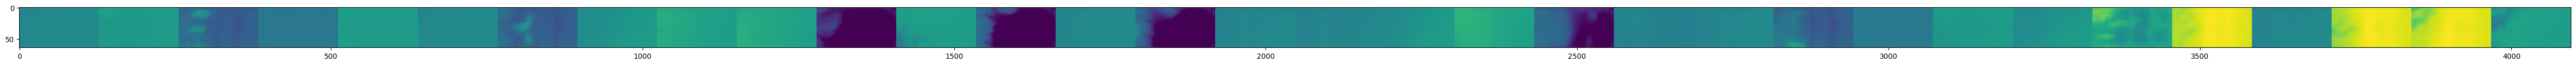

In [19]:
data_dir = '../results/test_transformer_best_99_1_decode_50%/output.png'

img = Image.open(data_dir)
arr = np.array(img)[:,:,0]
fig, ax = plt.subplots(figsize=(64,1))
ax.imshow(arr, cmap = 'viridis')

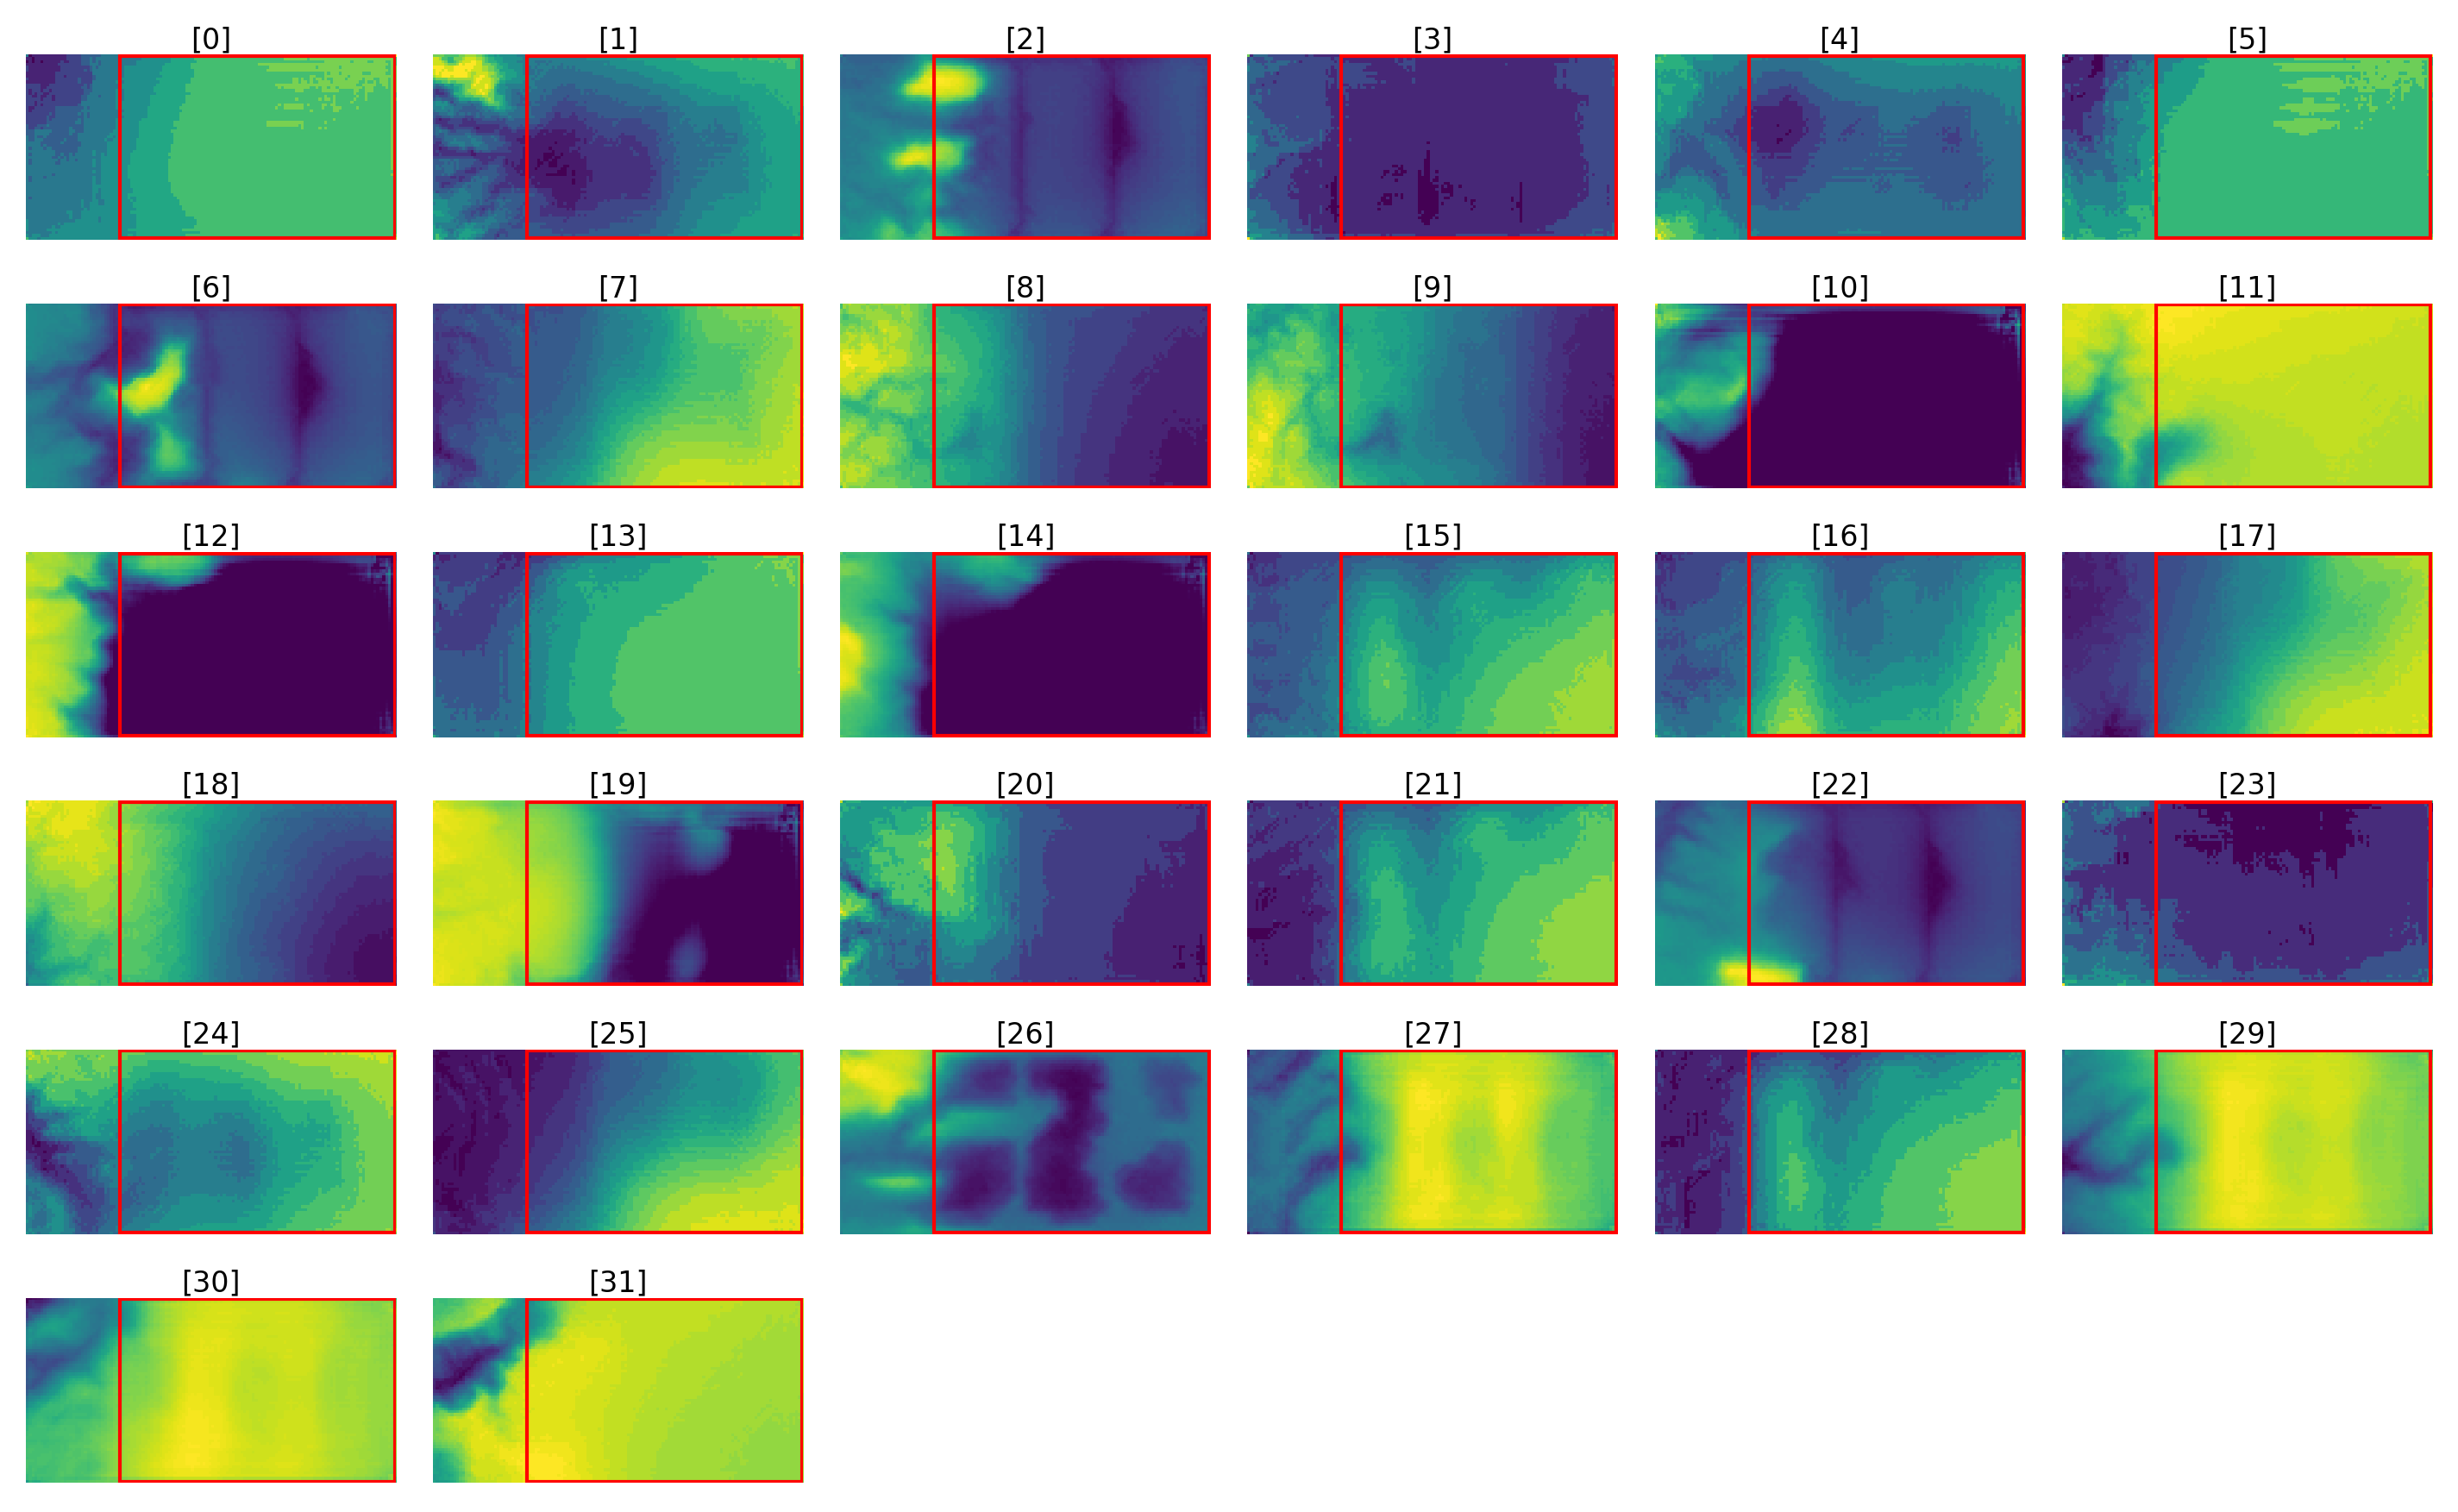

In [30]:
data_dir = "../results/test_transformer_best_99_1_decode_50%/output.png"
# Load image and select first channel
img = Image.open(data_dir)
arr = np.array(img)[:, :, 0]

# Determine grid size (128 wide x 64 tall images)
img_size_width = 128
img_size_height = 64
num_images = arr.shape[1] // img_size_width  # Total sub-images in the strip

# Calculate square grid dimensions
cols = int(np.ceil(np.sqrt(num_images)))
rows = int(np.ceil(num_images / cols))

# Create figure with high DPI for sharp resolution and zooming
fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * 2, rows * 1.2),  # Adjusted ratio to match 128x64 aspect
    dpi=300,
    gridspec_kw={"wspace": 0.1, "hspace": 0.3},
)

# Reshape and plot each sub-image
axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i in range(len(axes_flat)):
    ax = axes_flat[i]
    if i < num_images:
        # Extract individual 128x64 tile
        tile = arr[:, i * img_size_width : (i + 1) * img_size_width]
        ax.imshow(tile, cmap="viridis")

        # Label image with index
        ax.set_title(f"[{i}]", fontsize=8, pad=2)

        # Draw a thin red bounding box around the right 96 pixels (right 3/4)
        # Bounding box starts at x = 128 - 96 = 32, y = 0
        rect = patches.Rectangle(
            (32, 0),
            96 - 1,
            img_size_height - 1,
            linewidth=1,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)

    # Hide coordinate axes
    ax.axis("off")

plt.show()